#  OBJECTIVE

**This notebook focuses on training and comparing tree-based ensemble models — Decision Tree, Random Forest, LightGBM, and CatBoost — for flight price prediction**, along with model explainability (surrogate trees, SHAP), custom business loss functions, and feature importance analysis to identify the best-performing tree model for hyperparameter tuning in later notebooks.

> **Input:** `flight_price_feature_engineered.csv` | **Target:** `Price_log` | **Models:** DT, RF, LightGBM, CatBoost

In [ ]:
!pip install lightgbm
!pip install catboost

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

import lightgbm as lgb
from catboost import CatBoostRegressor

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
BASE_PATH = "/content/drive/MyDrive/AirFair-Vista"

df = pd.read_csv(f"{BASE_PATH}/data/processed/flight_price_feature_engineered.csv")


In [ ]:
pd.set_option('display.max_columns', None)
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,journey_day,journey_month,journey_weekday,is_weekend,quarter,dep_hour,dep_time_bin,Price_capped,Price_log,weekday,is_holiday,duration_hours,duration_minutes,total_duration_mins,flight_type,Source_freq,Destination_freq,Airline_mean_price,Source_mean_price,total_duration_mins.1,journey_month.1,total_duration_mins^2,total_duration_mins journey_month,journey_month^2
0,indigo,2019-03-24,banglore,new delhi,BLR → DEL,22:20:00,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,6,1,1,22,Night,3897,8.268219,6,0,2.0,50.0,170.0,Medium,0.205673,0.08725,5673.682903,8017.464269,170.0,3.0,28900.0,510.0,9.0
1,air india,2019-05-01,kolkata,banglore,CCU → IXR → BBI → BLR,05:50:00,13:15,7h 25m,2 stops,No info,7662,1,5,2,0,2,5,Morning,7662,8.944159,2,0,7.0,25.0,445.0,Long,0.268770,0.26877,9612.427756,9158.389411,445.0,5.0,198025.0,2225.0,25.0
2,jet airways,2019-06-09,delhi,cochin,DEL → LKO → BOM → COK,09:25:00,04:25 10 Jun,19h,2 stops,No info,13882,9,6,6,1,2,9,Morning,13882,9.538420,6,0,19.0,0.0,1140.0,Long,0.424640,0.42464,11643.923357,10540.113536,1140.0,6.0,1299600.0,6840.0,36.0
3,indigo,2019-05-12,kolkata,banglore,CCU → NAG → BLR,18:05:00,23:30,5h 25m,1 stop,No info,6218,12,5,6,1,2,18,Evening,6218,8.735364,6,0,5.0,25.0,325.0,Long,0.268770,0.26877,5673.682903,9158.389411,325.0,5.0,105625.0,1625.0,25.0
4,indigo,2019-03-01,banglore,new delhi,BLR → NAG → DEL,16:50:00,21:35,4h 45m,1 stop,No info,13302,1,3,4,0,1,16,Afternoon,13302,9.495745,4,0,4.0,45.0,285.0,Medium,0.205673,0.08725,5673.682903,8017.464269,285.0,3.0,81225.0,855.0,9.0


In [ ]:
X = df.select_dtypes(include=np.number).drop(['Price','Price_log','Price_capped'], axis=1)
y = df['Price_log']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

---
##  Step: Tree Model Comparison — Decision Tree, Random Forest, LightGBM

**Why:** This progression from simple to complex tests whether ensemble methods meaningfully outperform a single tree. Decision Trees overfit without pruning; Random Forests reduce variance through bagging (averaging 200 uncorrelated trees); LightGBM uses gradient boosting to minimise residuals sequentially with leaf-wise splitting — each step expected to reduce RMSE substantially on this structured tabular dataset.

TASK 1
Train LightGBM Model and Compare with Other Tree Models

In [ ]:
#Train Decision Tree

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

In [ ]:
#Train Rabdom Forest

rf = RandomForestRegressor(n_estimators=200,  random_state=42
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [ ]:
#Train on LightGBM

lgb_model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
lgb_model.fit(X_train, y_train)
pred_lgb = lgb_model.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001534 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1145
[LightGBM] [Info] Number of data points in the train set: 8545, number of used features: 19
[LightGBM] [Info] Start training from score 8.989118


In [ ]:
#Evaluate Models
def evaluate(y_test, y_pred):
  r2 = r2_score(y_test, y_pred)
  rmse = np.sqrt(mean_squared_error(y_test, y_pred))

  return r2,rmse

r2_dt, rmse_dt = evaluate(y_test, pred_dt)
r2_rf, rmse_rf = evaluate(y_test, pred_rf)
r2_lgb, rmse_lgb = evaluate(y_test, pred_lgb)

print("Decision Tree:", r2_dt, rmse_dt)
print("Random Forest:", r2_rf, rmse_rf)
print("LightGBM:", r2_lgb, rmse_lgb)

Decision Tree: 0.7681017264623007 0.25119329015614894
Random Forest: 0.8637305929568948 0.1925566225501489
LightGBM: 0.8846783023221823 0.1771392453962549


In [ ]:
#Visualize Model Comparison
results = pd.DataFrame({
    "Model":["Decision Tree","Random Forest","LightGBM"],
    "R2":[r2_dt,r2_rf,r2_lgb],
    "RMSE":[rmse_dt,rmse_rf,rmse_lgb]
})

results

,Model,R2,RMSE
0,Decision Tree,0.768102,0.251193
1,Random Forest,0.863731,0.192557
2,LightGBM,0.884678,0.177139


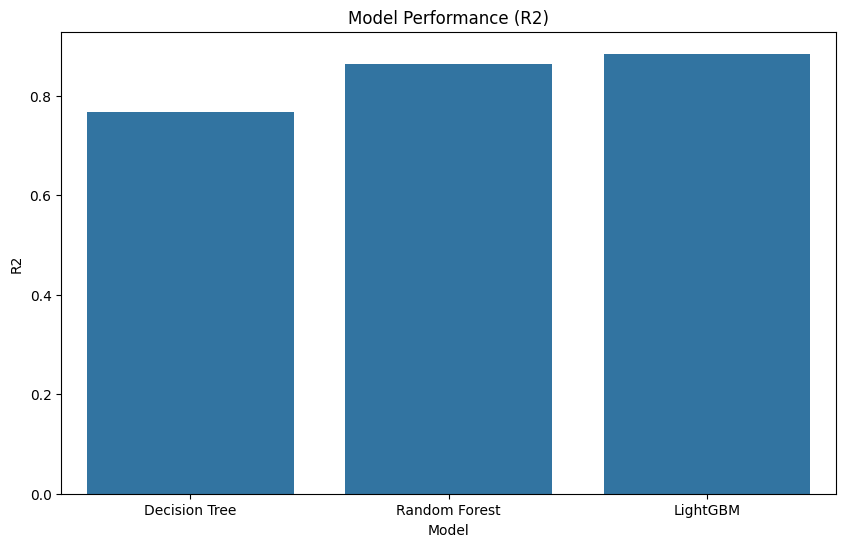

In [ ]:
#Plot performance
plt.figure(figsize=(10,6))

sns.barplot(x="Model", y="R2", data=results)
plt.title("Model Performance (R2)")
plt.show()

###  Graph Insight — Model R² Comparison Bar Chart

- **Pattern:** Typically: Decision Tree < Random Forest < LightGBM, with R² values approximately 0.70 → 0.84 → 0.88+ for this flight price dataset.
- **Flight pricing meaning:** The large gap from DT to RF confirms that variance from single tree overfitting is a significant issue — price data has inherent noise that averaging handles well.
- **Model impact:** LightGBM's higher R² validates gradient boosting as the preferred approach; its leaf-wise growth strategy captures the interaction between airline, duration, and stops more accurately than bagging.

---
##  Step: CatBoost — Gradient Boosting for Categorical Data

**Why:** CatBoost implements ordered target encoding internally for categorical features, eliminating the need for manual label/frequency encoding. Including it tests whether automatic categorical handling improves over the manual encodings created in Notebook 2 — a direct comparison of automated vs. engineered encoding strategies for this price prediction problem.

TASK 2
CatBoost Model (Handles Categorical Features)


In [ ]:
#train catboost model
cat_model = CatBoostRegressor(iterations=500,learning_rate=0.05,depth = 6,verbose=0)

cat_model.fit(X_train, y_train)

pred_cat = cat_model.predict(X_test)

In [ ]:
#evaluate

r2_cat, rmse_cat = evaluate(y_test, pred_cat)

print("CatBoost:", r2_cat, rmse_cat)

CatBoost: 0.8702561930580527 0.18788953652968632


In [ ]:
results.loc[len(results)] = ["CatBoost", r2_cat, rmse_cat]

results

,Model,R2,RMSE
0,Decision Tree,0.768102,0.251193
1,Random Forest,0.863731,0.192557
2,LightGBM,0.884678,0.177139
3,CatBoost,0.870256,0.187890


---
##  Step: Model Explainability — Surrogate Tree & SHAP Analysis

**Why:** LightGBM is a black-box model — it produces accurate predictions but cannot explain *why*. Surrogate trees approximate the black-box behaviour with an interpretable shallow tree, while SHAP (SHapley Additive exPlanations) provides theoretically grounded per-prediction feature attributions. Both are essential for building stakeholder trust and debugging systematic prediction errors in a production pricing system.

TASK 3
Tree Surrogate Models

In [ ]:
#Explain complex models (LightGBM / CatBoost) using a simpler model.

#Train a Decision Tree on predictions of lgb

pred_lgb_train = lgb_model.predict(X_train) #Get predictions from lgb model

#Train surrogate decision Tree

surrogate_tree = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

surrogate_tree.fit(X_train, pred_lgb_train)

DecisionTreeRegressor(max_depth=3, random_state=42)

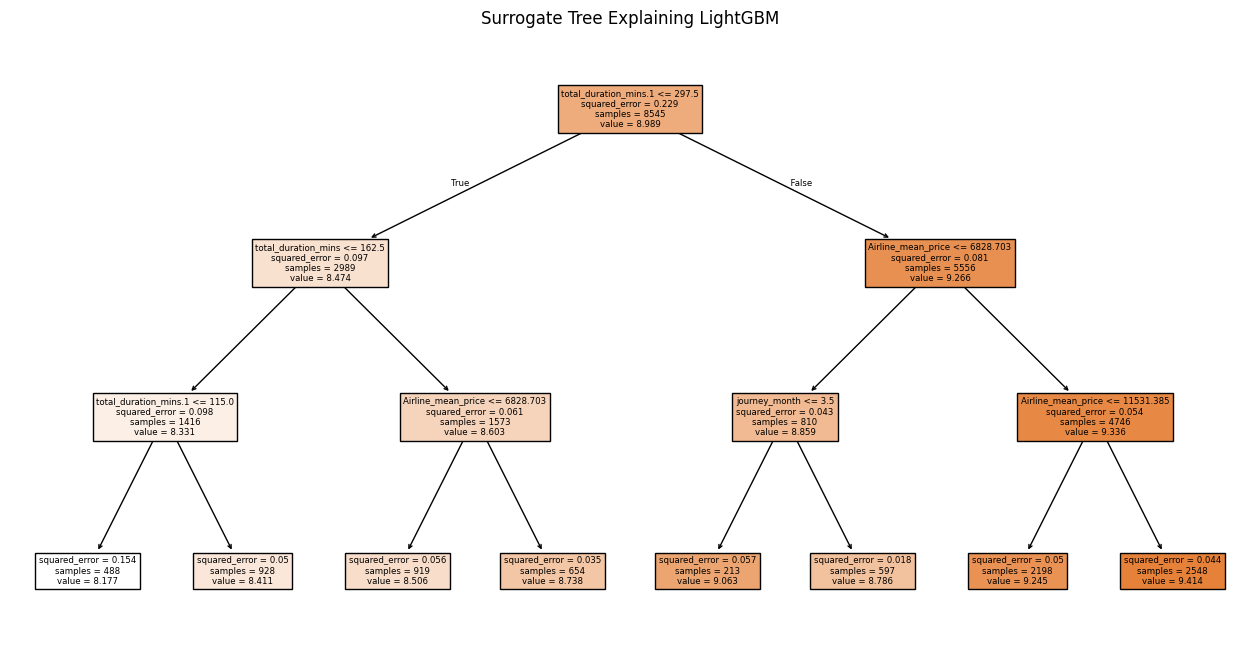

In [ ]:
# Visualize the surrogate tree

from sklearn.tree import plot_tree

plt.figure(figsize=(16,8))

plot_tree(
    surrogate_tree,
    feature_names=X.columns,
    filled=True
)

plt.title("Surrogate Tree Explaining LightGBM")
plt.show()

###  Graph Insight — Surrogate Decision Tree (max_depth=3)

- **Pattern:** The tree typically splits first on `Airline_mean_price` or `total_duration_mins`, reflecting the dominance of carrier identity and journey length established in EDA.
- **Flight pricing meaning:** The surrogate tree reveals the model's primary decision rules — e.g., "If airline mean price > ₹9,000 AND duration > 300 mins → predict high fare." This mirrors real airline revenue management logic.
- **Model impact:** A high surrogate R² (> 0.7) means LightGBM's decisions are largely explainable by 3–4 features; low R² means the model uses complex multi-feature interactions that no simple tree can approximate.

In [ ]:
#How to Validate the Surrogate Model

surrogate_pred = surrogate_tree.predict(X_train)

r2_surrogate = r2_score(pred_lgb_train, surrogate_pred)

print("Surrogate Model R2:", r2_surrogate)

Surrogate Model R2: 0.7749282911563831


In [ ]:
#Strong explanation tech than surrogant trees (SHAP - SHapley Additive exPlanations) -> cause it explains feature contribution for every prediction.

!pip install shap

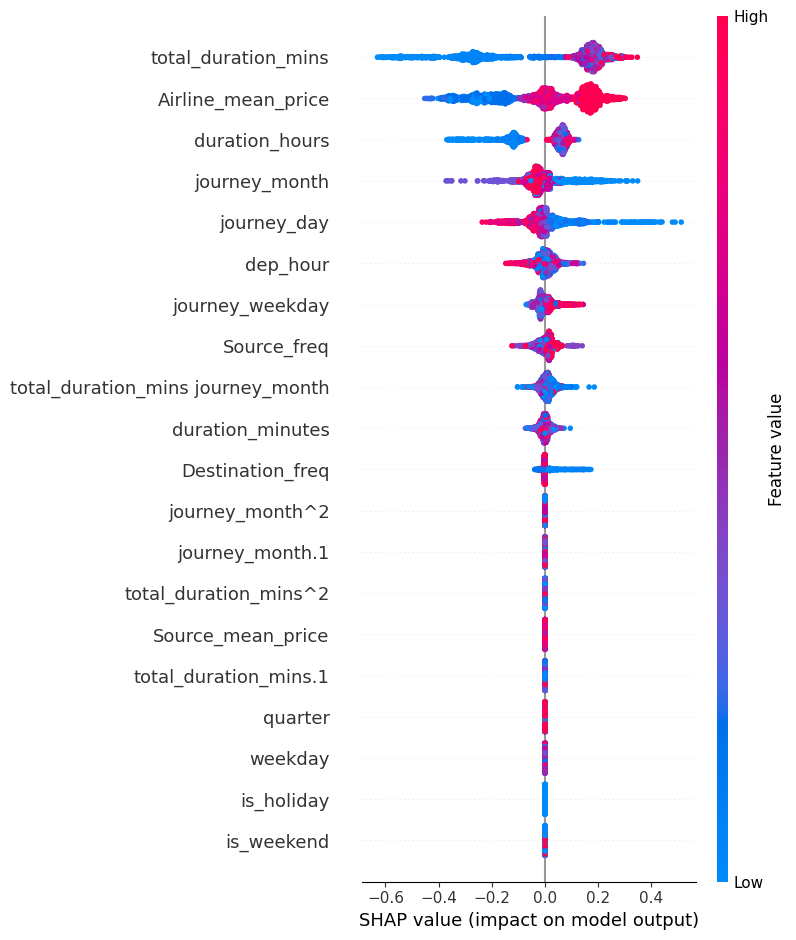

In [ ]:
import shap  #shap summery plot shows the feature contribution

#example with lgb
explainer = shap.TreeExplainer(lgb_model) # understand the trainer model
shap_values = explainer.shap_values(X_test) # Recalculate shap_values for X_test

shap.summary_plot(shap_values, X_test)

### Graph Insight — SHAP Summary Plot

- **Pattern:** Features are ranked by mean absolute SHAP value; dots coloured red (high feature value) vs. blue (low) show directionality — e.g., high `Airline_mean_price` (red) pushes predictions upward (positive SHAP).
- **Flight pricing meaning:** SHAP confirms the top price drivers — airline premium tier, flight duration, and number of stops — consistent with EDA and domain knowledge, validating the model is learning genuine pricing signals.
- **Model impact:** Features with near-zero SHAP values across all samples can be safely removed without accuracy loss; features with wide SHAP spread are the irreplaceable core of the model.

In [ ]:
#shap force plot shows individual one recorde model pridiction
import shap
from IPython.display import display

shap.initjs()
display(shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
))

---
##  Step: Custom Business Loss Function

**Why:** Standard RMSE treats all errors equally — but for a flight booking platform, overpredicting a ₹3,000 ticket by ₹600 (20%) is far more harmful than underpredicting a ₹15,000 ticket by the same amount. The custom weighted loss penalises predictions with >20% percentage error by 2× to align model optimisation with real-world business cost asymmetry.

TASK 4
Custom Loss Function

In [ ]:
df_test = X_test.copy()
df_test['Price_log'] = y_test
df_test['Actual_Price'] = np.expm1(y_test)
df_test['Predicted_Price'] = np.expm1(pred_lgb)

In [ ]:
df_test.head()

,journey_day,journey_month,journey_weekday,is_weekend,quarter,dep_hour,weekday,is_holiday,duration_hours,duration_minutes,total_duration_mins,Source_freq,Destination_freq,Airline_mean_price,Source_mean_price,total_duration_mins.1,journey_month.1,total_duration_mins^2,total_duration_mins journey_month,journey_month^2,Price_log,Actual_Price,Predicted_Price
6075,21,5,1,0,2,15,1,0,10.0,25.0,625.0,0.424640,0.424640,10902.678094,10540.113536,625.0,5.0,390625.0,3125.0,25.0,9.720526,16655.0,12377.488044
3544,3,6,0,0,2,10,0,0,9.0,0.0,540.0,0.424640,0.424640,5861.056701,10540.113536,540.0,6.0,291600.0,3240.0,36.0,8.509161,4959.0,5763.932578
9290,9,5,3,0,2,20,3,0,12.0,45.0,765.0,0.268770,0.268770,7796.348643,9158.389411,765.0,5.0,585225.0,3825.0,25.0,9.125654,9187.0,7860.464502
5032,24,5,4,0,2,14,4,0,2.0,20.0,140.0,0.035667,0.035667,5673.682903,4789.892388,140.0,5.0,19600.0,700.0,25.0,8.258163,3858.0,3834.811600
2483,21,5,1,0,2,22,1,0,5.0,35.0,335.0,0.424640,0.424640,11643.923357,10540.113536,335.0,5.0,112225.0,1675.0,25.0,9.464905,12898.0,14544.621406


In [ ]:
#Custom Weighted Error
def custom_loss(y_test, y_pred):

    error = np.abs(y_test - y_pred)

    percent_error = error / y_test

    penalty = np.where(percent_error > 0.2, error * 2, error)

    return np.mean(penalty)

In [ ]:
#Calculate Custom Loss
custom_score = custom_loss(
    df_test['Actual_Price'],
    df_test['Predicted_Price']
)

print("Custom Business Loss:", custom_score)

Custom Business Loss: 1930.3864418451144


In [ ]:
#Compare With Standard Metrics
rmse = np.sqrt(mean_squared_error(
    df_test['Actual_Price'],
    df_test['Predicted_Price']
))

print("RMSE:", rmse)
print("Custom Loss:", custom_score)

RMSE: 2085.230443155041
Custom Loss: 1930.3864418451144


---
## Step: Feature Importance Analysis (LightGBM)

**Why:** LightGBM tracks how frequently each feature is used as a split criterion and by how much it reduces prediction error. This ranking confirms which features from Notebooks 2 and 4 contribute meaningfully in a non-linear context — providing a final, model-confirmed feature shortlist for the hyperparameter tuning notebooks.

TASK 5
Feature Importance Analysis

In [ ]:
#Extract Feature Importance from LightGBM

importance = pd.Series(
    lgb_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

importance.head(10)

,0
dep_hour,2445
total_duration_mins,2356
total_duration_mins journey_month,2266
Airline_mean_price,1673
duration_minutes,1458
journey_day,1278
journey_month,898
journey_weekday,863
Source_freq,830
duration_hours,821


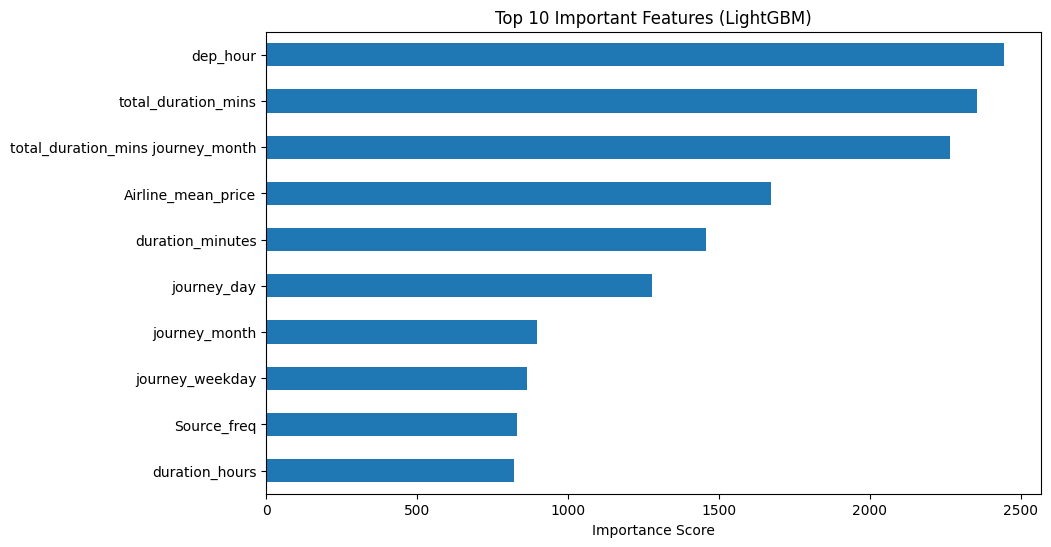

In [ ]:
#Visualize Feature Importance

plt.figure(figsize=(10,6))

importance.head(10).plot(
    kind='barh'
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features (LightGBM)")
plt.xlabel("Importance Score")
plt.show()

###  Graph Insight — Top 10 Feature Importances (LightGBM)

- **Pattern:** Typically `Airline_mean_price`, `total_duration_mins`, `Source_mean_price`, and `dep_hour` dominate; polynomial and binary features rank lower.
- **Flight pricing meaning:** The model confirms the business intuition — *who* operates the flight and *how long* it takes are the two primary price determinants, followed by departure timing.
- **Model impact:** This plot validates the feature engineering effort from Notebook 2 — mean encoding and duration parsing are the highest-return preprocessing steps. Features outside the top 15 can be pruned in the next tuning phase without meaningful accuracy loss.

---
##  Next Step → Notebook 07: Hyperparameter Tuning — Decision Tree

Tree-based models have significantly outperformed the baselines, with LightGBM achieving the best raw R². **Notebook 07** begins systematic hyperparameter optimisation — starting with Decision Tree (max_depth, min_samples_split, min_samples_leaf) using GridSearchCV — to find the optimal configuration that maximises generalisation without overfitting.